Evaluate and visualise: 


Qualitatively inspect clusters: do they correspond to intuitive genres/moods (e.g. high-energy dance vs. calm acoustic)?


If the dataset has existing genre labels, compute basic cluster quality metrics (e.g. purity, silhouette score) as a sanity check.


Use dimensionality-reduction methods (t-SNE or UMAP) to visualise the music space in 2D and highlight discovered clusters.



Test it with ourselves. Get our own user info:

Params
user (Required) : The user name to fetch top tracks for.
period (Optional) : overall | 7day | 1month | 3month | 6month | 12month - The time period over which to retrieve top tracks for.
limit (Optional) : The number of results to fetch per page. Defaults to 50.
page (Optional) : The page number to fetch. Defaults to first page.
api_key (Required) : A Last.fm API key.

Can we make an algorithm that given our most heard songs and artists last year, can recommend for example 10 new songs, we havn't heard before that we like


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

notebook_dir = Path.cwd().resolve()

project_root = notebook_dir
while not (project_root / "artifacts").exists() and project_root.parent != project_root:
    project_root = project_root.parent

artifact_dir = project_root / "artifacts"

full_df_path = artifact_dir / "full_dataset_clean.csv"
features_csv_path = artifact_dir / "features_apt_all_weighted.csv"

if not full_df_path.exists():
    raise FileNotFoundError(full_df_path)
if not features_csv_path.exists():
    raise FileNotFoundError(features_csv_path)

full_df = pd.read_csv(full_df_path)
features_df = pd.read_csv(features_csv_path)

full_df["track_id"] = full_df["track_id"].astype(str)
features_df["track_id"] = features_df["track_id"].astype(str)

common_ids = pd.Index(features_df["track_id"]).intersection(full_df["track_id"])

features_df = (
    features_df.set_index("track_id")
    .loc[common_ids]
    .reset_index()
)
full_df = (
    full_df.set_index("track_id")
    .loc[common_ids]
    .reset_index()
)

assert len(full_df) == len(features_df)

feature_cols = [c for c in features_df.columns if c != "track_id"]

X_main = features_df[feature_cols].to_numpy(dtype=np.float32)

id_to_index = {tid: i for i, tid in enumerate(full_df["track_id"])}
index_to_id = {i: tid for tid, i in id_to_index.items()}

full_df.head()


,track_id,artists,track_name,track_genre,search_string,duration_ms,tempo,tempo_log,duration_minutes,tags_clean_text,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lfm_playcount,lfm_listeners,log_playcount,log_listeners,log_plays_per_listener,plays_per_listener,tag_count
0,4ckoZlzQTOTEN8rhfQPbBl,Dirty Audio;Gold,No Stoppin (feat. GOLD),electronic,"No Stoppin (feat. GOLD) - Dirty Audio, Gold",160000,149.963,5.010389,2.666667,electronic usa dubstep us united state united states of america trap,0.00975,0.615,0.996,0.000142,0.0657,-0.953,0.0810,0.0797,12115.0,3312.0,9.402282,8.105609,1.538567,3.657911,7
1,3CRtbOoAP82y0VbPO5j1ft,Sasha Alex Sloan,Too Sad To Cry,electro,Too Sad To Cry - Sasha Alex Sloan,208986,120.483,4.791509,3.483100,my top song indie-pop female vocalist indie pop acoustic deezer 4-25 name variation upcoming album 2024,0.84200,0.515,0.270,0.000000,0.1140,-9.935,0.0357,0.2340,671709.0,80945.0,13.417582,11.301538,2.229836,8.298338,10
2,265SFiKBPvo5ojatV1egRk,AronChupa;Little Sis Nora,The Woodchuck Song,swedish,"The Woodchuck Song - AronChupa, Little Sis Nora",154394,126.031,4.836528,2.573233,dance electronic sweden swedish edm pop-dance club humour house hip-hop,0.01650,0.898,0.770,0.002160,0.2070,-4.970,0.3020,0.4120,228630.0,33475.0,12.339865,10.418584,2.057946,6.829873,9
3,7oQ8pTAe783QS0UwOmbHRb,Busy Signal;Mavado,Full Clip - feat. Mavado,j-dance,"Full Clip - feat. Mavado - Busy Signal, Mavado",184466,100.112,4.606290,3.074433,dancehall reggae ragga jamaican bashment busy signal jamaica caribbean all reggea,0.02610,0.726,0.692,0.000000,0.1180,-5.084,0.3340,0.5380,939.0,281.0,6.845880,5.641907,1.468251,3.341637,10
4,46Rgoqf0TIsHPudbaaqUP0,George Jones;Tammy Wynette,Did You Ever?,honky-tonk,"Did You Ever? - George Jones, Tammy Wynette",127813,74.278,4.307815,2.130217,country classic country singer-songwriter george jone americana traditional country honky tonk texa male vocalist am...,0.68500,0.613,0.295,0.000000,0.1050,-9.896,0.0303,0.8120,1262.0,453.0,7.141245,6.118097,1.331276,2.785872,10


In [2]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

n_clusters = full_df["track_genre"].nunique()
print("Number of distinct genres:", n_clusters)

X_for_clustering = X_main

kmeans_main = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans_main.fit_predict(X_for_clustering)

full_df["cluster_kmeans_main"] = cluster_labels

cluster_sizes = full_df["cluster_kmeans_main"].value_counts().sort_index()
cluster_sizes.head()


Number of distinct genres: 113


cluster_kmeans_main
0    563
1    378
2    210
3    686
4    455
Name: count, dtype: int64

In [3]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import pandas as pd

n_samples = X_main.shape[0]
max_sample = 10000

if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    sample_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    sample_indices = np.arange(n_samples)

X_sample = X_main[sample_indices]
labels_sample = full_df.loc[sample_indices, "cluster_kmeans_main"].to_numpy()

silhouette_avg = silhouette_score(X_sample, labels_sample, metric="euclidean")
silhouette_vals = silhouette_samples(X_sample, labels_sample, metric="euclidean")

silhouette_df = pd.DataFrame(
    {
        "cluster": labels_sample,
        "silhouette": silhouette_vals,
    }
)

cluster_silhouette_summary = (
    silhouette_df.groupby("cluster")["silhouette"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

cluster_sizes = full_df["cluster_kmeans_main"].value_counts().sort_index()

print(f"Silhouette score (sample of {len(sample_indices)} tracks): {silhouette_avg:.3f}")
print()
print("Cluster size summary:")
print(cluster_sizes.describe())
print()
cluster_silhouette_summary.head()


Silhouette score (sample of 10000 tracks): 0.185

Cluster size summary:
count     113.000000
mean      487.867257
std       432.864638
min        86.000000
25%       252.000000
50%       417.000000
75%       589.000000
max      3527.000000
Name: count, dtype: float64



,mean,median,count
cluster,,,
28,0.853484,0.862837,23
15,0.817308,0.824579,42
16,0.811166,0.816819,30
55,0.763224,0.787547,23
96,0.760786,0.769764,17


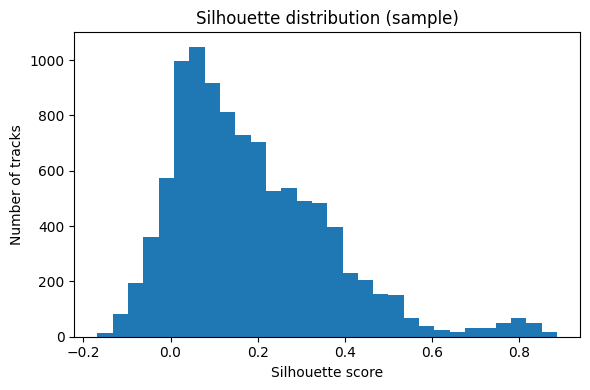

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(silhouette_vals, bins=30)
plt.xlabel("Silhouette score")
plt.ylabel("Number of tracks")
plt.title("Silhouette distribution (sample)")
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

genres = full_df["track_genre"].fillna("unknown").astype(str)
clusters = full_df["cluster_kmeans_main"].to_numpy()

crosstab = pd.crosstab(clusters, genres)

majority_counts = crosstab.max(axis=1)
purity = majority_counts.sum() / len(full_df)

nmi = normalized_mutual_info_score(genres, clusters)
ari = adjusted_rand_score(genres, clusters)

print(f"Overall purity: {purity:.3f}")
print(f"NMI (clusters vs. track_genre): {nmi:.3f}")
print(f"ARI (clusters vs. track_genre): {ari:.3f}")


Overall purity: 0.469
NMI (clusters vs. track_genre): 0.584
ARI (clusters vs. track_genre): 0.229


In [6]:
cluster_sizes = full_df["cluster_kmeans_main"].value_counts().sort_values(ascending=False)
top_clusters = cluster_sizes.head(10).index

top_crosstab = crosstab.loc[top_clusters]

top_crosstab


track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,breakbeat,british,cantopop,chicago-house,children,chill,classical,club,comedy,country,...,romance,sad,salsa,samba,sertanejo,show-tunes,singer-songwriter,ska,sleep,soul,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
cluster_kmeans_main,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
34,17,110,12,14,10,36,1,12,16,70,32,9,4,35,148,14,4,72,40,13,...,3,29,78,39,88,39,19,19,3,2,57,77,16,6,4,19,15,6,58,9
9,117,24,11,7,23,28,0,7,18,65,1,24,4,1,76,56,25,28,24,21,...,101,49,30,14,26,84,48,3,25,14,43,226,6,5,16,2,0,2,42,15
6,6,0,0,0,53,43,2,0,0,1,0,11,1,0,1,8,106,7,0,1,...,21,7,0,0,0,5,0,0,355,0,0,101,0,1,0,0,0,1,1,89
7,327,46,5,0,79,0,2,20,4,11,0,95,0,0,3,8,0,7,1,11,...,44,1,0,1,0,0,43,1,0,0,8,2,1,0,0,0,1,0,7,4
93,17,0,6,0,0,1,0,0,2,0,0,0,3,0,3,2,0,0,0,0,...,0,0,0,0,0,0,0,35,0,0,10,0,1,0,0,0,0,0,0,0
13,68,1,160,14,27,17,0,4,25,10,0,37,0,0,0,2,0,0,3,1,...,0,1,0,0,0,0,6,21,0,1,3,0,6,0,0,1,0,0,5,0
89,30,0,33,17,5,2,0,0,12,0,0,22,2,0,0,62,0,45,0,3,...,0,11,0,0,0,0,29,0,0,8,67,0,12,36,0,0,1,0,6,0
32,0,41,0,4,0,59,0,0,2,96,0,0,2,0,0,18,0,1,52,16,...,0,71,0,0,0,0,0,4,0,3,32,0,4,0,0,3,0,0,37,0
8,0,0,5,4,0,1,0,0,0,1,0,3,0,0,0,3,0,8,0,0,...,0,2,0,0,0,0,0,0,0,6,3,5,52,42,0,14,2,0,0,0


In [7]:
genre_sizes = full_df["track_genre"].value_counts().sort_values(ascending=False)
top_genres = genre_sizes.head(10).index

top_crosstab_genres = crosstab[top_genres].loc[top_clusters]

top_crosstab_genres


track_genre,comedy,black-metal,grindcore,bluegrass,study,heavy-metal,afrobeat,club,idm,ambient
cluster_kmeans_main,,,,,,,,,,
34,40,1,1,12,77,4,110,72,10,10
9,24,0,2,7,226,1,24,28,11,23
6,0,2,0,0,101,1,0,7,29,53
7,1,2,0,20,2,0,46,7,0,79
93,0,0,0,0,0,0,0,0,0,0
13,3,0,0,4,0,0,1,0,0,27
89,0,0,0,0,0,0,0,45,0,5
32,52,0,0,0,0,0,41,1,0,0
8,0,0,0,0,5,0,0,8,0,0


In [8]:
from sklearn.decomposition import PCA
import numpy as np

n_samples = X_main.shape[0]
max_sample = 20000

if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    vis_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    vis_indices = np.arange(n_samples)

X_vis = X_main[vis_indices]
clusters_vis = full_df.loc[vis_indices, "cluster_kmeans_main"].to_numpy()
genres_vis = full_df.loc[vis_indices, "track_genre"].astype("category")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_vis)

pca_explained = pca.explained_variance_ratio_
pca_explained


array([0.03867828, 0.02371533], dtype=float32)

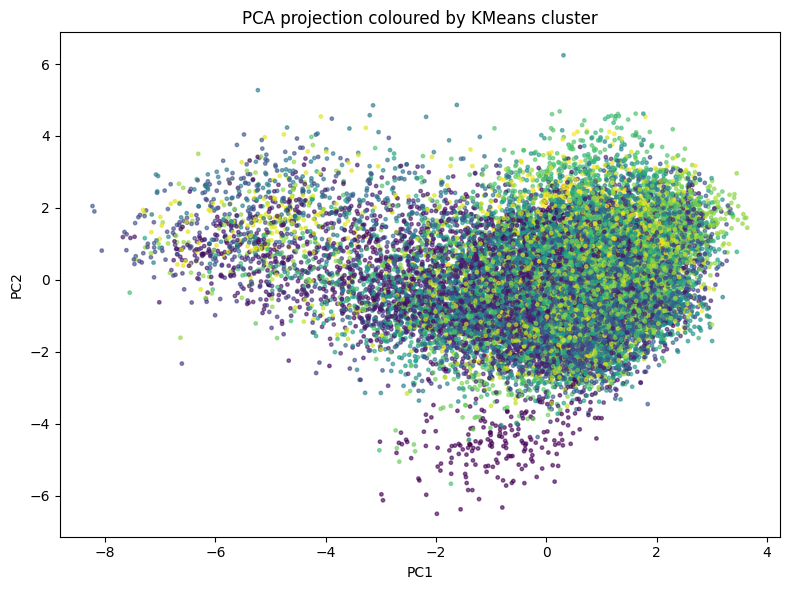

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_vis,
    s=6,
    alpha=0.6,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection coloured by KMeans cluster")
plt.tight_layout()
plt.show()


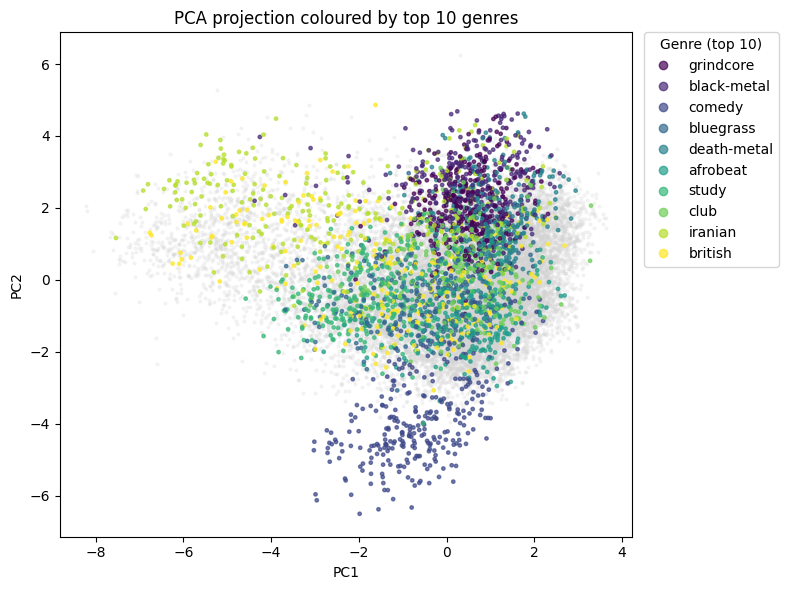

In [10]:
genre_counts = genres_vis.value_counts()
top_genres = genre_counts.head(10).index

color_labels = np.full(len(genres_vis), -1, dtype=int)
for i, g in enumerate(top_genres):
    mask = genres_vis == g
    color_labels[mask.to_numpy()] = i

mask_top = color_labels >= 0
mask_other = ~mask_top

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[mask_other, 0],
    X_pca[mask_other, 1],
    s=4,
    alpha=0.2,
    color="lightgray",
)
scatter = plt.scatter(
    X_pca[mask_top, 0],
    X_pca[mask_top, 1],
    c=color_labels[mask_top],
    s=6,
    alpha=0.7,
)

handles, _ = scatter.legend_elements(num=len(top_genres))
labels = [str(g) for g in top_genres]
plt.legend(
    handles,
    labels,
    title="Genre (top 10)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.0,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection coloured by top 10 genres")
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd

numeric_cols_candidate = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "valence",
    "tempo_log",
    "duration_minutes",
    "log_playcount",
    "log_listeners",
    "log_plays_per_listener",
    "tag_count",
]

numeric_cols = [c for c in numeric_cols_candidate if c in full_df.columns]

cluster_summary = (
    full_df.groupby("cluster_kmeans_main")[numeric_cols]
    .mean()
    .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
    .sort_values("size", ascending=False)
)

cluster_summary.head(10)


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo_log,duration_minutes,log_playcount,log_listeners,log_plays_per_listener,tag_count,size
cluster_kmeans_main,,,,,,,,,,,,,,,
34,0.241432,0.664733,0.721237,0.077808,0.218913,-6.464071,0.101688,0.634982,4.896312,3.469956,8.395721,7.009453,1.636231,3.348738,3527
9,0.568746,0.585543,0.441882,0.113921,0.176966,-9.975311,0.072466,0.442457,4.617523,3.343731,8.309498,6.989696,1.588203,3.265370,2879
6,0.864423,0.338119,0.206865,0.786857,0.184046,-22.554548,0.057126,0.171028,4.574769,3.281429,8.541346,7.174785,1.647837,2.459176,1335
7,0.581165,0.518583,0.450146,0.079271,0.167660,-10.264602,0.046362,0.400895,4.750812,3.688361,11.580482,9.945469,1.826089,9.094231,1040
93,0.048205,0.452756,0.871660,0.030947,0.224906,-4.917474,0.076688,0.541780,4.904230,3.155380,10.554722,8.801129,1.922652,9.090997,1033
13,0.161696,0.515575,0.723263,0.042347,0.187745,-6.342257,0.056313,0.486745,4.805111,3.689533,12.989954,11.100040,2.041390,8.771047,974
89,0.346328,0.584064,0.581813,0.093311,0.180611,-7.823925,0.059530,0.468303,4.785544,3.432179,12.429945,10.540818,2.040593,8.604013,947
32,0.260014,0.712948,0.658000,0.014004,0.188626,-7.195045,0.196364,0.537125,4.742277,3.446415,11.138044,9.173270,2.107518,7.464883,897
8,0.125934,0.691880,0.764078,0.051635,0.194701,-5.980182,0.079117,0.623676,4.808952,3.507853,11.359330,9.676696,1.873339,8.296343,793


In [12]:
from collections import Counter

def top_tags_for_cluster(cluster_id, top_n=10):
    mask = full_df["cluster_kmeans_main"] == cluster_id
    tags_series = full_df.loc[mask, "tags_clean_text"].fillna("")
    counter = Counter()
    for s in tags_series:
        if not s:
            continue
        for t in s.split():
            counter[t] += 1
    return counter.most_common(top_n)

top_tags_for_cluster(0, top_n=10)


[('comedy', 1291),
 ('stand-up', 994),
 ('spoken', 256),
 ('word', 256),
 ('all', 231),
 ('comedian', 229),
 ('funny', 218),
 ('standup', 193),
 ('stand', 133),
 ('up', 133)]

In [13]:
from sklearn.metrics import pairwise_distances

def representative_tracks(cluster_id, top_n=5):
    mask = full_df["cluster_kmeans_main"] == cluster_id
    indices = np.where(mask.to_numpy())[0]
    if len(indices) == 0:
        return full_df.iloc[[]]

    center = kmeans_main.cluster_centers_[cluster_id]
    X_cluster = X_main[indices]
    dists = pairwise_distances(X_cluster, center.reshape(1, -1), metric="euclidean").ravel()
    order = np.argsort(dists)[:top_n]
    chosen = indices[order]
    return full_df.loc[chosen, ["track_id", "artists", "track_name", "track_genre"]]

representative_tracks(0, top_n=5)


,track_id,artists,track_name,track_genre
16136,6ibDrp6aS9sKTtqFcNwEWc,Kyle Kinane,Salt,comedy
23044,5NDVx9nNrF1Ytu8gSo1PZE,Rachel Feinstein,Facebook and Judging People,comedy
13896,232JYqcGAakh5zqaMGzSoR,Kyle Kinane,Sodium Erythortbate,comedy
55019,1m0cS6nJHKgqZjPj6hgWNR,Kyle Kinane,This Track Is Not Called Quiet on Tha Set,comedy
47669,1g3CAvWIDLVgrBwS5R1IY5,Kyle Kinane,This Track Is Not Called Parental Discretion Iz Advised,comedy


In [14]:
def describe_cluster(cluster_id, top_n_tags=10, top_n_tracks=5):
    mask = full_df["cluster_kmeans_main"] == cluster_id
    size = mask.sum()
    genres = full_df.loc[mask, "track_genre"].value_counts().head(5)
    means = full_df.loc[mask, numeric_cols].mean()

    print(f"Cluster {cluster_id}")
    print(f"Size: {size}")
    print("\nTop genres:")
    print(genres)
    print("\nMean feature profile:")
    print(means.round(3))
    print("\nTop tags:")
    print(top_tags_for_cluster(cluster_id, top_n=top_n_tags))
    print("\nRepresentative tracks:")
    display(representative_tracks(cluster_id, top_n=top_n_tracks))

describe_cluster(cluster_summary.index[0])


Cluster 34
Size: 3527

Top genres:
track_genre
kids        296
forro       201
party       153
children    148
malay       138
Name: count, dtype: int64

Mean feature profile:
acousticness              0.241
danceability              0.665
energy                    0.721
instrumentalness          0.078
liveness                  0.219
loudness                 -6.464
speechiness               0.102
valence                   0.635
tempo_log                 4.896
duration_minutes          3.470
log_playcount             8.396
log_listeners             7.009
log_plays_per_listener    1.636
tag_count                 3.349
dtype: float64

Top tags:
[('pop', 557), ('rock', 471), ('brazilian', 432), ('brazil', 380), ('vocalist', 318), ('brasil', 292), ('electronic', 243), ('female', 207), ('all', 199), ('american', 199)]

Representative tracks:


,track_id,artists,track_name,track_genre
28630,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids
26620,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
52645,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
39486,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
48268,6JilFqhtGTaEdKH6EYf10j,Kevi Jonny,Arranhão,forro


In [15]:
from collections import Counter
import pandas as pd
import numpy as np

def summarize_user_profile(matched_df: pd.DataFrame, user_name: str | None = None):
    total = len(matched_df)
    if total == 0:
        print("No top tracks fetched for this user.")
        return

    df_in = matched_df[matched_df["in_dataset"] & matched_df["track_id"].notna()].copy()
    covered = len(df_in)
    coverage = covered / total

    title = f"User profile summary for {user_name}" if user_name else "User profile summary"
    print(title)
    print(f"Top tracks from Last.fm: {total}")
    print(f"Matched in dataset: {covered} ({coverage:.1%})")

    if covered == 0:
        print("No matched tracks, cannot summarise clusters or genres.")
        return

    cluster_counts = df_in["cluster_kmeans_main"].value_counts().sort_values(ascending=False)
    print("\nTop clusters (by matched tracks):")
    print(cluster_counts.head(10))

    merged = df_in.merge(
        full_df[["track_id", "track_genre"]],
        on="track_id",
        how="left",
    )
    genre_counts = merged["track_genre"].value_counts().sort_values(ascending=False)
    print("\nTop genres (for matched tracks):")
    print(genre_counts.head(10))


In [ ]:
df_andreas_top = fetch_lastfm_top_tracks("AndreasUsername", api_key=LASTFM_API_KEY)
df_andreas_matched = match_user_tracks_to_dataset(df_andreas_top, full_df)
summarize_user_profile(df_andreas_matched, user_name="Andreas")


In [22]:
find_similar_songs("HUMBLE.", "Kendrick Lamar")

NameError: name 'find_similar_songs' is not defined

In [23]:
from sklearn.neighbors import NearestNeighbors
import unicodedata, re

def strip_accents(text: str) -> str:
    return "".join(ch for ch in unicodedata.normalize("NFKD", text) if not unicodedata.combining(ch))

REMOVE_BRACKETS_RE = re.compile(r"\([^)]*\)|\[[^\]]*\]")
NON_ALNUM_RE = re.compile(r"[^a-z0-9]+")
SPACE_RE = re.compile(r"\s+")

def normalize_text(value: str) -> str:
    if not isinstance(value, str):
        return ""
    text = value.lower().strip()
    text = REMOVE_BRACKETS_RE.sub(" ", text)
    text = strip_accents(text)
    text = NON_ALNUM_RE.sub(" ", text)
    return SPACE_RE.sub(" ", text).strip()

knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(X_main)  # X_main comes from your first cell (features_apt_all_weighted.csv)

def _match_rows(df: pd.DataFrame, title: str, artist: str | None):
    title_mask = df["track_name"].str.lower().fillna("") == title.lower()
    artist_mask = (
        df["artists"].str.lower().fillna("").str.contains(artist.lower()) if artist else True
    )
    return title_mask & artist_mask

def find_similar_songs(title: str, artist: str | None = None, k: int = 10):
    mask = _match_rows(full_df, title, artist)
    if not mask.any():
        normalized_title = normalize_text(title)
        normalized_artist = normalize_text(artist) if artist else None
        alt_df = full_df.assign(
            track_name=full_df["track_name"].map(normalize_text),
            artists=full_df["artists"].map(normalize_text),
        )
        mask = _match_rows(alt_df, normalized_title, normalized_artist)
    if not mask.any():
        print(f"Track not found: {title} — {artist or 'any artist'}")
        return
    idx = mask[mask].index[0]
    row = full_df.loc[idx]
    distances, indices = knn.kneighbors(X_main[idx: idx + 1], n_neighbors=k + 1)
    print(f"Seed track: {row['track_name']} — {row['artists']}")
    for rank, neighbor_idx in enumerate(indices[0][1:], start=1):
        neighbor = full_df.iloc[neighbor_idx]
        print(f"  {rank}. {neighbor['track_name']} — {neighbor['artists']} (cosine {distances[0][rank]:.3f})")


In [24]:
find_similar_songs("HUMBLE.", "Kendrick Lamar")

Seed track: HUMBLE. — Kendrick Lamar
  1. R.I.P. — Playboi Carti (cosine 0.026)
  2. SICKO MODE — Travis Scott (cosine 0.038)
  3. INDUSTRY BABY (feat. Jack Harlow) — Lil Nas X;Jack Harlow (cosine 0.039)
  4. Pass — Nizi19;Karamel19 (cosine 0.064)
  5. Best Friend — Young Thug (cosine 0.075)
  6. BUTTERFLY EFFECT — Travis Scott (cosine 0.085)
  7. Look At Me! — XXXTENTACION (cosine 0.101)
  8. Trap Queen — Fetty Wap (cosine 0.102)
  9. RECON — Justin Stone (cosine 0.113)
  10. N95 — Kendrick Lamar (cosine 0.113)
